In [ ]:
import zipfile

zip_path = "/content/archive (21).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)

/content/dataset
/content/dataset/no
/content/dataset/brain_tumor_dataset
/content/dataset/brain_tumor_dataset/no
/content/dataset/brain_tumor_dataset/yes
/content/dataset/yes


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [ ]:
dataset_path = "/content/dataset/brain_tumor_dataset"

yes_path = os.path.join(dataset_path,"yes")
no_path = os.path.join(dataset_path,"no")

In [ ]:
print("Tumor Images =", len(os.listdir(yes_path)))
print("No Tumor Images =", len(os.listdir(no_path)))

Tumor Images = 155
No Tumor Images = 98


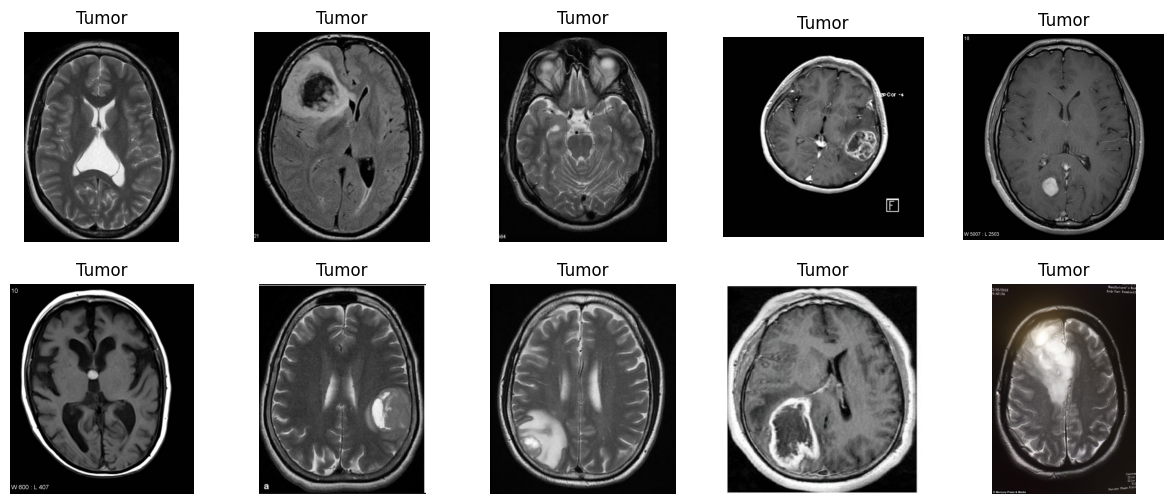

In [ ]:
files = os.listdir(yes_path)

plt.figure(figsize=(15,6))

for i in range(10):

    img = cv2.imread(os.path.join(yes_path,files[i]))

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(2,5,i+1)

    plt.imshow(img)

    plt.title("Tumor")

    plt.axis("off")

plt.show()

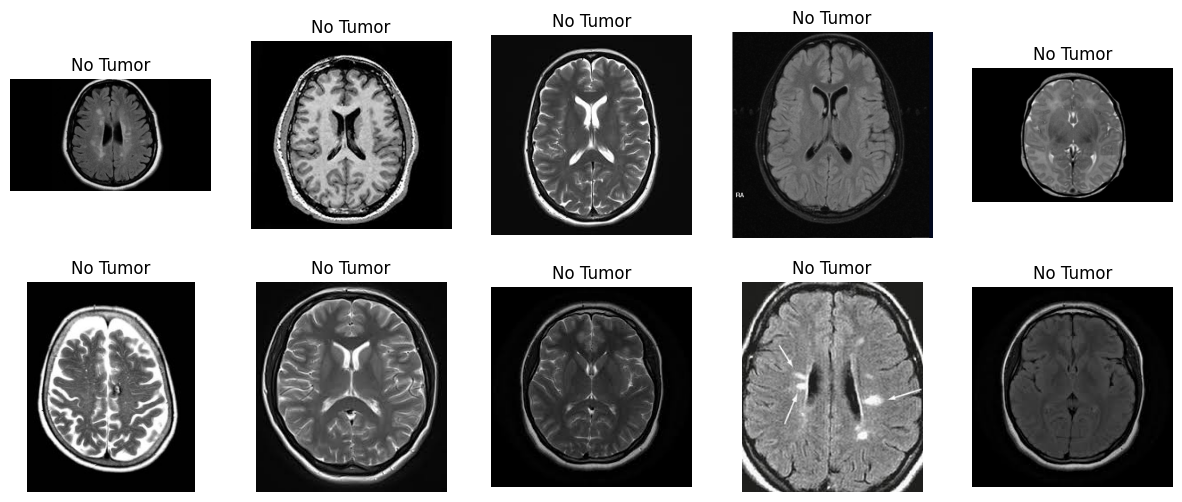

In [ ]:
files = os.listdir(no_path)

plt.figure(figsize=(15,6))

for i in range(10):

    img = cv2.imread(os.path.join(no_path,files[i]))

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(2,5,i+1)

    plt.imshow(img)

    plt.title("No Tumor")

    plt.axis("off")

plt.show()

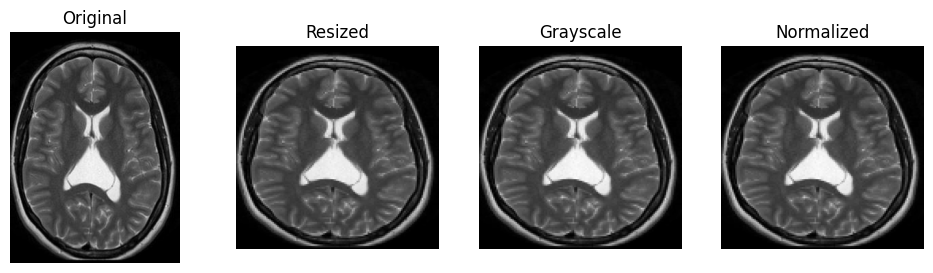

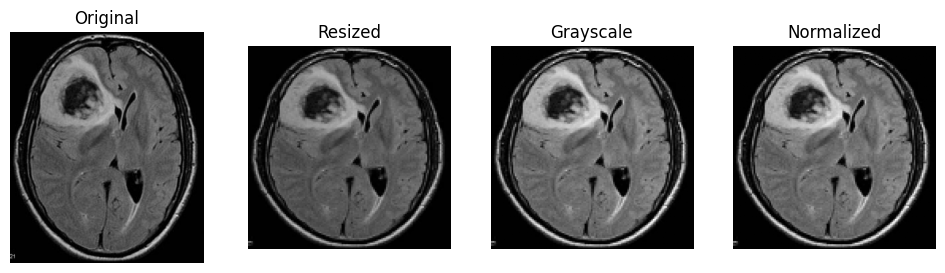

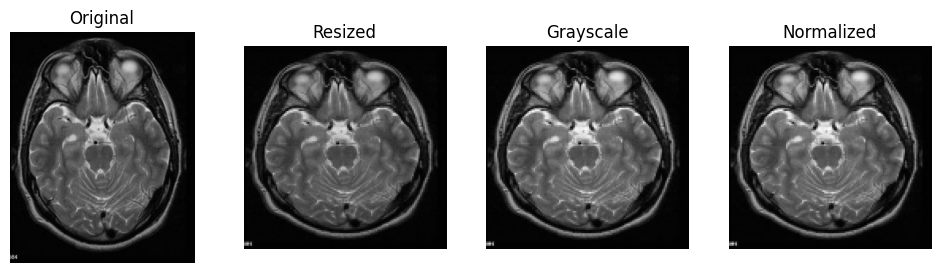

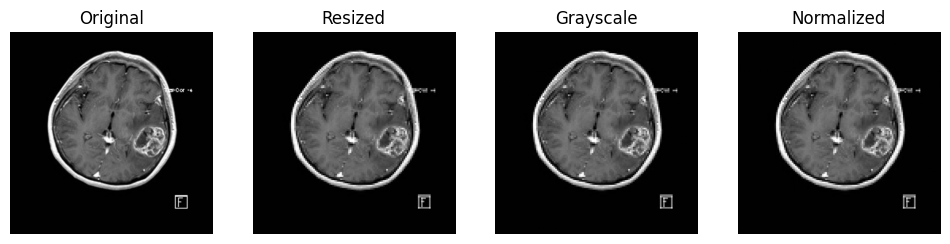

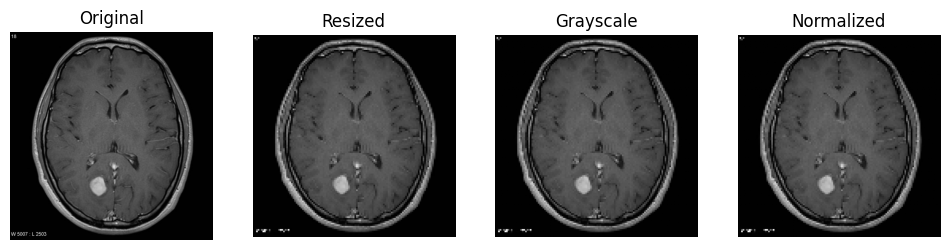

In [ ]:
files = os.listdir(yes_path)

for i in range(5):

    img = cv2.imread(os.path.join(yes_path,files[i]))

    original = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    resized = cv2.resize(original,(128,128))

    gray = cv2.cvtColor(resized,cv2.COLOR_RGB2GRAY)

    normalized = gray/255.0

    plt.figure(figsize=(12,3))

    plt.subplot(1,4,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(resized)
    plt.title("Resized")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(gray,cmap="gray")
    plt.title("Grayscale")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(normalized,cmap="gray")
    plt.title("Normalized")
    plt.axis("off")

    plt.show()

In [ ]:
features = []
labels = []

In [ ]:
for file in os.listdir(yes_path):

    path = os.path.join(yes_path,file)

    img = cv2.imread(path)

    img = cv2.resize(img,(128,128))

    img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    img = img/255.0

    feature = hog(img)

    features.append(feature)

    labels.append(1)

In [ ]:
for file in os.listdir(no_path):

    path = os.path.join(no_path,file)

    img = cv2.imread(path)

    img = cv2.resize(img,(128,128))

    img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    img = img/255.0

    feature = hog(img)

    features.append(feature)

    labels.append(0)

In [ ]:
X = np.array(features)

y = np.array(labels)

print("Feature Shape =",X.shape)

print("Label Shape =",y.shape)

Feature Shape = (253, 15876)
Label Shape = (253,)


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model = SVC(kernel="rbf")

model.fit(X_train,y_train)

SVC()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy =",accuracy)

Accuracy = 0.8431372549019608


In [ ]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.93      0.65      0.76        20
           1       0.81      0.97      0.88        31

    accuracy                           0.84        51
   macro avg       0.87      0.81      0.82        51
weighted avg       0.86      0.84      0.84        51



In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WhatsApp Image 2026-06-12 at 2.53.24 PM.jpeg to WhatsApp Image 2026-06-12 at 2.53.24 PM.jpeg


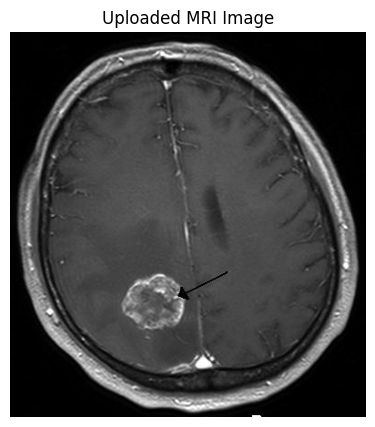

Brain Tumor Detected


In [ ]:
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog

# Get uploaded image name
image_path = list(uploaded.keys())[0]

# Read image
test_img = cv2.imread(image_path)

# Display image
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.title("Uploaded MRI Image")
plt.axis("off")
plt.show()

# Preprocessing
test_img = cv2.resize(test_img, (128,128))

test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)

test_img = test_img / 255.0

# HOG feature extraction
test_feature = hog(test_img)

test_feature = test_feature.reshape(1,-1)

# Prediction
prediction = model.predict(test_feature)

if prediction[0] == 1:
    print("Brain Tumor Detected")
else:
    print("No Brain Tumor Detected")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WhatsApp Image 2026-06-12 at 2.55.19 PM.jpeg to WhatsApp Image 2026-06-12 at 2.55.19 PM.jpeg


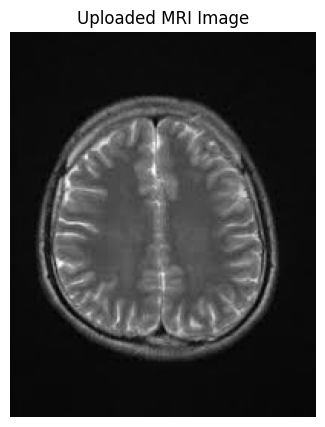

No Brain Tumor Detected


In [ ]:
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog

# Get uploaded image name
image_path = list(uploaded.keys())[0]

# Read image
test_img = cv2.imread(image_path)

# Display image
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.title("Uploaded MRI Image")
plt.axis("off")
plt.show()

# Preprocessing
test_img = cv2.resize(test_img, (128,128))

test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)

test_img = test_img / 255.0

# HOG feature extraction
test_feature = hog(test_img)

test_feature = test_feature.reshape(1,-1)

# Prediction
prediction = model.predict(test_feature)

if prediction[0] == 1:
    print("Brain Tumor Detected")
else:
    print("No Brain Tumor Detected")